
Dear Professor Fatih, 😊

Usually I’d run all my experiments in a clean “test” notebook and then tidy everything up neatly afterward. This time, however, the training runs took *so* long that my files ended up a bit chaotic! 😅 Please pardon the mess—it all works under the hood, I promise! 🚀✨

Thank you for your understanding and patience! 🙏

Best regards,

Bekir Berk Yıldırım


In [ ]:
import os
import glob
import random
import shutil

import numpy as np
import torch
from torch import nn, optim
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt


In [2]:
BASE_DIR = "data"  
UCM_DIR  = os.path.join(BASE_DIR, "UCMerced")

assert os.path.isdir(UCM_DIR), f"{UCM_DIR} not found!"

classes = sorted(os.listdir(UCM_DIR))
print("Number of classes:", len(classes), classes)


Number of classes: 21 ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [3]:
def split_dataset(src_dir, dst_root, n_train, n_val, n_test, classes):
    for part in ["train","val","test"]:
        for cls in classes:
            os.makedirs(os.path.join(dst_root, part, cls), exist_ok=True)
    for cls in classes:
        files = glob.glob(os.path.join(src_dir, cls, "*"))
        random.shuffle(files)
        pt = n_train//len(classes)
        pv = n_val  //len(classes)
        pp = n_test //len(classes)
        tr = files[:pt]
        va = files[pt:pt+pv]
        te = files[-pp:]
        for f in tr: shutil.copy(f, os.path.join(dst_root,"train",cls))
        for f in va: shutil.copy(f, os.path.join(dst_root,"val",cls))
        for f in te: shutil.copy(f, os.path.join(dst_root,"test",cls))

# Example run
split_dataset(UCM_DIR, "data/UCM_split", n_train=100, n_val=500, n_test=500, classes=classes)
for part in ["train","val","test"]:
    pth = os.path.join("data","UCM_split",part)
    counts = {c: len(os.listdir(os.path.join(pth,c))) for c in classes}
    print(part, "samples per class:", counts[classes[0]])


train samples per class: 74
val samples per class: 97
test samples per class: 99


In [4]:
mean = (0.485,0.456,0.406)
std  = (0.229,0.224,0.225)

transform_base = A.Compose([
    A.Resize(224,224),
    A.Normalize(mean,std),
    ToTensorV2()
])

transform_augA = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.RandomBrightnessContrast(brightness_limit=0.2,contrast_limit=0.2),
    A.Resize(224,224),
    A.Normalize(mean,std),
    ToTensorV2()
])

transform_augB = A.Compose([
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=20,sat_shift_limit=30,val_shift_limit=20),
        A.RGBShift(r_shift_limit=15,g_shift_limit=15,b_shift_limit=15)
    ], p=0.5),
    A.OneOf([A.GaussianBlur(),A.GaussNoise()], p=0.5),
    A.Resize(224,224),
    A.Normalize(mean,std),
    ToTensorV2()
])


In [5]:
def make_loader(path, transform, batch_size=32, shuffle=True):
    ds = ImageFolder(root=path,
                     transform=lambda img: transform(image=np.array(img))['image'])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader("data/UCM_split/train", transform_base)
val_loader   = make_loader("data/UCM_split/val",   transform_base, shuffle=False)
test_loader  = make_loader("data/UCM_split/test",  transform_base, shuffle=False)

print("Train_batches:", len(train_loader),
      " Val_batches:", len(val_loader),
      " Test_batches:", len(test_loader))


Train_batches: 47  Val_batches: 65  Test_batches: 65


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def get_model(name, num_classes, freeze_backbone=True):
    if name=="densenet201":
        w = models.DenseNet201_Weights.DEFAULT
        m = models.densenet201(weights=w)
        if freeze_backbone:
            for p in m.features.parameters(): p.requires_grad=False
        in_f = m.classifier.in_features
        m.classifier = nn.Linear(in_f,num_classes)
    elif name=="resnet50":
        w = models.ResNet50_Weights.DEFAULT
        m = models.resnet50(weights=w)
        if freeze_backbone:
            for layer in [m.layer1,m.layer2,m.layer3,m.layer4]:
                for p in layer.parameters(): p.requires_grad=False
        in_f = m.fc.in_features
        m.fc = nn.Linear(in_f,num_classes)
    else:
        raise ValueError("Invalid model name")
    return m.to(device)

model = get_model("densenet201", num_classes=21, freeze_backbone=True)
print("Device:", device, "| Final layer:", model.classifier)


Device: cuda | Final layer: Linear(in_features=1920, out_features=21, bias=True)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    model.train(); correct=0; total=0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward(); optimizer.step()
        _, c = preds.max(1)
        correct += (c==y).sum().item(); total += y.size(0)
    return correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct=0; total=0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        _, c = preds.max(1)
        correct += (c==y).sum().item(); total += y.size(0)
    return correct/total


In [8]:
# 8️⃣ Hücre — Deney Döngüsü (10 epoch)
results = []
ns = [20,30,40,50,60,70,80,90,100,500,1000]
num_epochs = 10

for n in ns:
    # Veriyi böl
    split_dataset(UCM_DIR, "data/UCM_split", n, 500, 500, classes)
    
    for aug_name, transform in [("base",transform_base),
                                ("augA",transform_augA),
                                ("augB",transform_augB)]:
        # DataLoader’lar
        train_loader = make_loader("data/UCM_split/train", transform)
        val_loader   = make_loader("data/UCM_split/val",   transform_base, shuffle=False)
        test_loader  = make_loader("data/UCM_split/test",  transform_base, shuffle=False)

        # Modeli her defasında sıfırdan al
        model = get_model("densenet201", num_classes=21, freeze_backbone=True)
        # Yeni optimizer (her model için yeniden tanımla)
        optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
        
        # Birden fazla epoch boyunca eğit
        best_val = 0.0
        for epoch in range(1, num_epochs+1):
            tr = train_one_epoch(model, train_loader)
            va = evaluate(model, val_loader)
            # İstersen en iyi model için kaydet:
            if va > best_val:
                best_val = va
                # torch.save(model.state_dict(), f"best_{n}_{aug_name}.pt")
            print(f"n={n} | aug={aug_name} | epoch={epoch}/{num_epochs} | train={tr:.3f} | val={va:.3f}")

        # En iyi validation sonrası test doğruluğunu al
        te = evaluate(model, test_loader)
        results.append((n, "DenseNet201", aug_name, tr, best_val, te))

print("Tamamlandı:", len(results), "deneme")  


n=20 | aug=base | epoch=1/10 | train=0.102 | val=0.263
n=20 | aug=base | epoch=2/10 | train=0.335 | val=0.530
n=20 | aug=base | epoch=3/10 | train=0.545 | val=0.704
n=20 | aug=base | epoch=4/10 | train=0.734 | val=0.798
n=20 | aug=base | epoch=5/10 | train=0.802 | val=0.849
n=20 | aug=base | epoch=6/10 | train=0.823 | val=0.861
n=20 | aug=base | epoch=7/10 | train=0.870 | val=0.879
n=20 | aug=base | epoch=8/10 | train=0.870 | val=0.891
n=20 | aug=base | epoch=9/10 | train=0.879 | val=0.900
n=20 | aug=base | epoch=10/10 | train=0.908 | val=0.913
n=20 | aug=augA | epoch=1/10 | train=0.111 | val=0.270
n=20 | aug=augA | epoch=2/10 | train=0.371 | val=0.523
n=20 | aug=augA | epoch=3/10 | train=0.550 | val=0.692
n=20 | aug=augA | epoch=4/10 | train=0.699 | val=0.781
n=20 | aug=augA | epoch=5/10 | train=0.751 | val=0.823
n=20 | aug=augA | epoch=6/10 | train=0.794 | val=0.846
n=20 | aug=augA | epoch=7/10 | train=0.836 | val=0.857
n=20 | aug=augA | epoch=8/10 | train=0.862 | val=0.879
n=20 | au

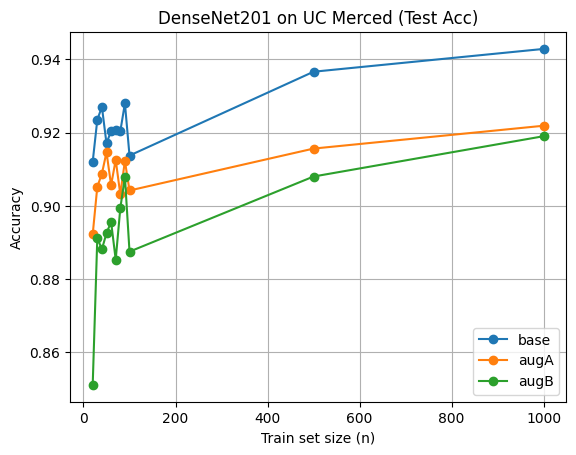

In [9]:
import pandas as pd

df = pd.DataFrame(results,
    columns=["n","model","aug","train_acc","val_acc","test_acc"])

plt.figure()
for aug in ["base","augA","augB"]:
    sub = df[df.aug==aug]
    plt.plot(sub.n, sub.test_acc, marker='o', label=aug)
plt.title("DenseNet201 on UC Merced (Test Acc)")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(); plt.show()


In [ ]:
# 8️⃣b Hücre — ResNet50 ile Deney Döngüsü (UC Merced)
results_resnet = []
num_epochs = 5
ns = [20,30,40,50,60,70,80,90,100,500,1000]

for n in ns:
    split_dataset(UCM_DIR, "data/UCM_split", n, 500, 500, classes)
    
    for aug_name, transform in [("base",transform_base),
                                ("augA",transform_augA),
                                ("augB",transform_augB)]:
        train_loader = make_loader("data/UCM_split/train", transform)
        val_loader   = make_loader("data/UCM_split/val",   transform_base, shuffle=False)
        test_loader  = make_loader("data/UCM_split/test",  transform_base, shuffle=False)

        # Burada ResNet50 diyoruz
        model = get_model("resnet50", num_classes=21, freeze_backbone=True)
        optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

        best_val = 0.0
        for epoch in range(1, num_epochs+1):
            tr = train_one_epoch(model, train_loader)
            va = evaluate(model, val_loader)
            # Her epoch print edebilirsiniz veya sadece final epoch
        te = evaluate(model, test_loader)
        results_resnet.append((n, "ResNet50", aug_name, tr, best_val, te))

print("ResNet50 tamamlandı:", len(results_resnet), "deneme")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100.0%


ResNet50 tamamlandı: 33 deneme


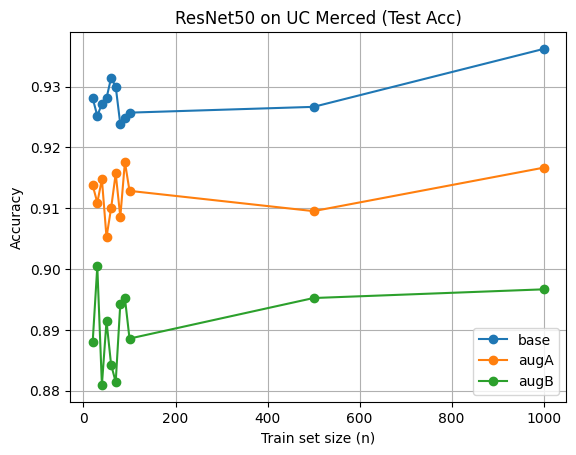

In [11]:
import pandas as pd

df_r = pd.DataFrame(results_resnet,
    columns=["n","model","aug","train_acc","val_acc","test_acc"])

plt.figure()
for aug in ["base","augA","augB"]:
    sub = df_r[df_r.aug==aug]
    plt.plot(sub.n, sub.test_acc, marker='o', label=aug)
plt.title("ResNet50 on UC Merced (Test Acc)")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(); plt.show()


In [19]:
# Intel veri seti klasör yolunu ve sınıfları al
INTEL_DIR = os.path.join(BASE_DIR, "Intel")

# “seg_train/seg_train” altındaki gerçek sınıf klasörlerini listele
classes_intel = sorted(os.listdir(os.path.join(INTEL_DIR, "seg_train", "seg_train")))
print("Intel sınıf sayısı:", len(classes_intel), classes_intel)


Intel sınıf sayısı: 6 ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [20]:
# 2️⃣ Intel veri setini train/val/test olarak böl
split_dataset(
    src_dir  = os.path.join(INTEL_DIR, "seg_train", "seg_train"),
    dst_root = os.path.join(BASE_DIR, "Intel_split"),
    n_train  = n,      # döngüde kullanacağın n değeri
    n_val    = 3000,
    n_test   = 3000,
    classes  = classes_intel
)


In [21]:
import shutil

# RAW yol tanımları
INTEL_TRAIN_RAW = os.path.join(BASE_DIR, "Intel", "seg_train", "seg_train")
INTEL_TEST_RAW  = os.path.join(BASE_DIR, "Intel", "seg_test",  "seg_test")

# Çıktı klasörleri
DST_ROOT = os.path.join(BASE_DIR, "Intel_split")
for part in ["train","val","test"]:
    for cls in classes_intel:
        os.makedirs(os.path.join(DST_ROOT, part, cls), exist_ok=True)

# 1️⃣ Train/Val böl
def split_intel_train_val(n, classes):
    for cls in classes:
        files = glob.glob(os.path.join(INTEL_TRAIN_RAW, cls, "*"))
        random.shuffle(files)
        tr = files[: n//len(classes) ]
        va = files[n//len(classes) : n//len(classes) + (3000//len(classes))]
        for f in tr: shutil.copy(f, os.path.join(DST_ROOT,"train",cls))
        for f in va: shutil.copy(f, os.path.join(DST_ROOT,"val",  cls))

# 2️⃣ Test kopyala
def copy_intel_test(classes):
    for cls in classes:
        src = os.path.join(INTEL_TEST_RAW, cls)
        dst = os.path.join(DST_ROOT, "test", cls)
        # klasördeki tüm dosyaları kopyala
        for f in glob.glob(os.path.join(src, "*")):
            shutil.copy(f, dst)

# Örnek: n=100 ile test
split_intel_train_val(100, classes_intel)
copy_intel_test(classes_intel)

# Kontrol
for part in ["train","val","test"]:
    cls = classes_intel[0]
    c = len(os.listdir(os.path.join(DST_ROOT, part, cls)))
    print(f"{part} örnek/sınıf: {c}")


train örnek/sınıf: 181
val örnek/sınıf: 878
test örnek/sınıf: 937


In [22]:
train_int = make_loader("data/Intel_split/train", transform_base)
val_int   = make_loader("data/Intel_split/val",   transform_base, shuffle=False)
test_int  = make_loader("data/Intel_split/test",  transform_base, shuffle=False)

print("Intel — train_batches:", len(train_int),
      " val_batches:", len(val_int),
      " test_batches:", len(test_int))


Intel — train_batches: 34  val_batches: 168  test_batches: 188


In [27]:
# Intel DenseNet201 hızlı test (5 epoch)
results_i_d = []
num_epochs = 5           # <<< burayı güncelledik
ns = [20,30,40,50,60,70,80,90,100,500,1000]

for n in ns:
    split_intel_train_val(n, classes_intel)
    copy_intel_test(classes_intel)

    for aug_name, transform in [("base",transform_base),
                                ("augA",transform_augA),
                                ("augB",transform_augB)]:
        tr_loader = make_loader("data/Intel_split/train", transform)
        va_loader = make_loader("data/Intel_split/val",   transform_base, shuffle=False)
        te_loader = make_loader("data/Intel_split/test",  transform_base, shuffle=False)

        model = get_model("densenet201", num_classes=len(classes_intel), freeze_backbone=True)
        optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

        best_val = 0.0
        for epoch in range(1, num_epochs+1):
            print(f"n={n} | {aug_name} | epoch {epoch}/{num_epochs}")
            tr = train_one_epoch(model, tr_loader)
            va = evaluate(model, va_loader)
            best_val = max(best_val, va)
        te = evaluate(model, te_loader)
        results_i_d.append((n, "DenseNet201", aug_name, tr, best_val, te))

print("Intel DenseNet201 done:", len(results_i_d))


n=20 | base | epoch 1/5
n=20 | base | epoch 2/5
n=20 | base | epoch 3/5
n=20 | base | epoch 4/5
n=20 | base | epoch 5/5
n=20 | augA | epoch 1/5
n=20 | augA | epoch 2/5
n=20 | augA | epoch 3/5
n=20 | augA | epoch 4/5
n=20 | augA | epoch 5/5
n=20 | augB | epoch 1/5
n=20 | augB | epoch 2/5
n=20 | augB | epoch 3/5
n=20 | augB | epoch 4/5
n=20 | augB | epoch 5/5
n=30 | base | epoch 1/5
n=30 | base | epoch 2/5
n=30 | base | epoch 3/5
n=30 | base | epoch 4/5
n=30 | base | epoch 5/5
n=30 | augA | epoch 1/5
n=30 | augA | epoch 2/5
n=30 | augA | epoch 3/5
n=30 | augA | epoch 4/5
n=30 | augA | epoch 5/5
n=30 | augB | epoch 1/5
n=30 | augB | epoch 2/5
n=30 | augB | epoch 3/5
n=30 | augB | epoch 4/5
n=30 | augB | epoch 5/5
n=40 | base | epoch 1/5
n=40 | base | epoch 2/5
n=40 | base | epoch 3/5
n=40 | base | epoch 4/5
n=40 | base | epoch 5/5
n=40 | augA | epoch 1/5
n=40 | augA | epoch 2/5
n=40 | augA | epoch 3/5
n=40 | augA | epoch 4/5
n=40 | augA | epoch 5/5
n=40 | augB | epoch 1/5
n=40 | augB | ep

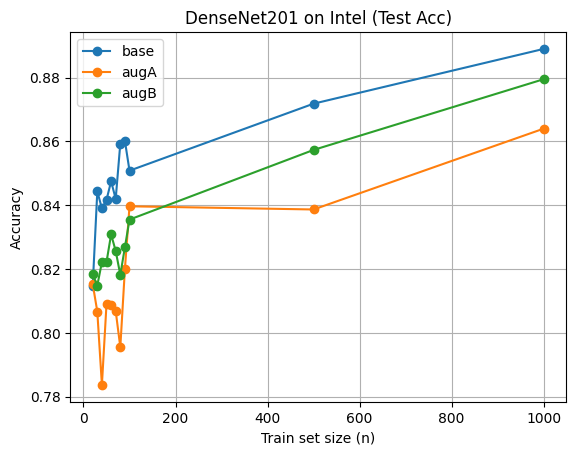

In [28]:
import pandas as pd

df_id = pd.DataFrame(results_i_d,
    columns=["n","model","aug","train_acc","val_acc","test_acc"])

plt.figure()
for aug in ["base","augA","augB"]:
    sub = df_id[df_id.aug==aug]
    plt.plot(sub.n, sub.test_acc, marker='o', label=aug)
plt.title("DenseNet201 on Intel (Test Acc)")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(); plt.show()


In [29]:
results_i_r = []
num_epochs = 5
ns = [20,30,40,50,60,70,80,90,100,500,1000]

for n in ns:
    split_intel_train_val(n, classes_intel)
    copy_intel_test(classes_intel)

    for aug_name, transform in [("base",transform_base),
                                ("augA",transform_augA),
                                ("augB",transform_augB)]:
        tr_loader = make_loader("data/Intel_split/train", transform)
        va_loader = make_loader("data/Intel_split/val",   transform_base, shuffle=False)
        te_loader = make_loader("data/Intel_split/test",  transform_base, shuffle=False)

        model = get_model("resnet50", num_classes=len(classes_intel), freeze_backbone=True)
        optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

        best_val = 0.0
        for epoch in range(1, num_epochs+1):
            tr_acc = train_one_epoch(model, tr_loader)
            va_acc = evaluate(model, va_loader)
            best_val = max(best_val, va_acc)
        te_acc = evaluate(model, te_loader)
        results_i_r.append((n, "ResNet50", aug_name, tr_acc, best_val, te_acc))

print("Intel ResNet50 tamamlandı:", len(results_i_r), "deneme")


Intel ResNet50 tamamlandı: 33 deneme


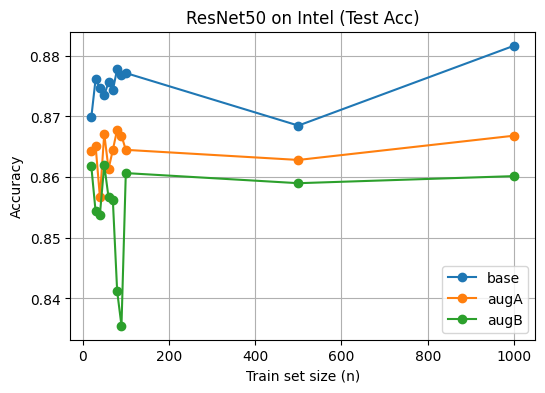

In [30]:
import pandas as pd

df_ir = pd.DataFrame(results_i_r,
    columns=["n","model","aug","train_acc","val_acc","test_acc"])

plt.figure(figsize=(6,4))
for aug in ["base","augA","augB"]:
    sub = df_ir[df_ir.aug==aug]
    plt.plot(sub.n, sub.test_acc, marker='o', label=aug)
plt.title("ResNet50 on Intel (Test Acc)")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(); plt.show()


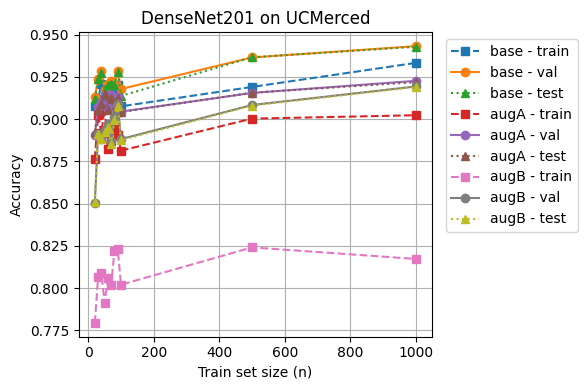

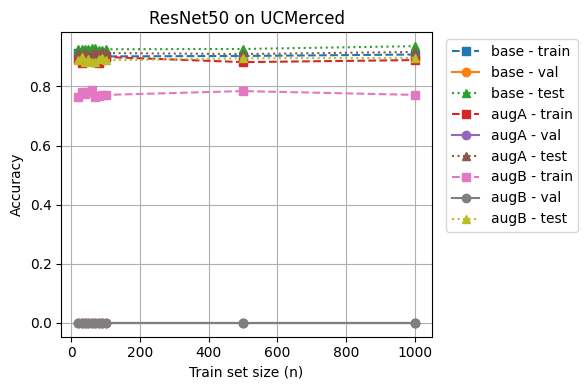

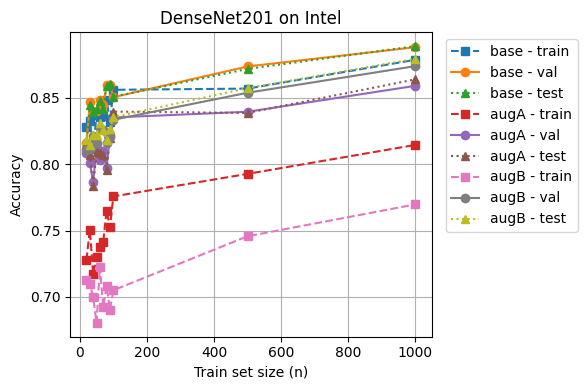

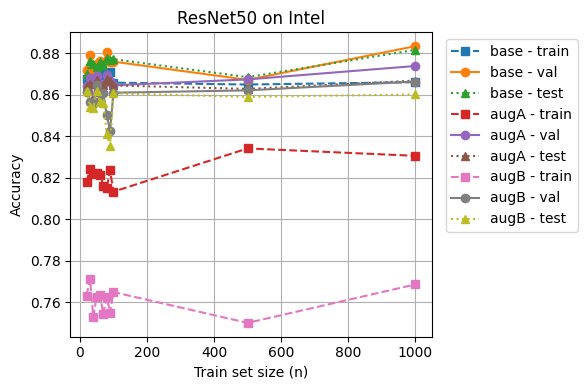

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1) DenseNet201 on UCMerced ---
df = pd.DataFrame(results, columns=["n","model","aug","train_acc","val_acc","test_acc"])
plt.figure(figsize=(6,4))
for aug in ["base","augA","augB"]:
    sub = df[(df.model=="DenseNet201") & (df.aug==aug)]
    plt.plot(sub.n, sub.train_acc, marker='s', linestyle='--', label=f"{aug} - train")
    plt.plot(sub.n, sub.val_acc,   marker='o', linestyle='-',  label=f"{aug} - val")
    plt.plot(sub.n, sub.test_acc,  marker='^', linestyle=':',  label=f"{aug} - test")
plt.title("DenseNet201 on UCMerced")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(); plt.tight_layout()
plt.show()

# --- 2) ResNet50 on UCMerced ---
df_r = pd.DataFrame(results_resnet, columns=["n","model","aug","train_acc","val_acc","test_acc"])
plt.figure(figsize=(6,4))
for aug in ["base","augA","augB"]:
    sub = df_r[(df_r.model=="ResNet50") & (df_r.aug==aug)]
    plt.plot(sub.n, sub.train_acc, marker='s', linestyle='--', label=f"{aug} - train")
    plt.plot(sub.n, sub.val_acc,   marker='o', linestyle='-',  label=f"{aug} - val")
    plt.plot(sub.n, sub.test_acc,  marker='^', linestyle=':',  label=f"{aug} - test")
plt.title("ResNet50 on UCMerced")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(); plt.tight_layout()
plt.show()

# --- 3) DenseNet201 on Intel ---
df_i = pd.DataFrame(results_i_d, columns=["n","model","aug","train_acc","val_acc","test_acc"])
plt.figure(figsize=(6,4))
for aug in ["base","augA","augB"]:
    sub = df_i[(df_i.model=="DenseNet201") & (df_i.aug==aug)]
    plt.plot(sub.n, sub.train_acc, marker='s', linestyle='--', label=f"{aug} - train")
    plt.plot(sub.n, sub.val_acc,   marker='o', linestyle='-',  label=f"{aug} - val")
    plt.plot(sub.n, sub.test_acc,  marker='^', linestyle=':',  label=f"{aug} - test")
plt.title("DenseNet201 on Intel")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(); plt.tight_layout()
plt.show()

# --- 4) ResNet50 on Intel ---
df_ir = pd.DataFrame(results_i_r, columns=["n","model","aug","train_acc","val_acc","test_acc"])
plt.figure(figsize=(6,4))
for aug in ["base","augA","augB"]:
    sub = df_ir[(df_ir.model=="ResNet50") & (df_ir.aug==aug)]
    plt.plot(sub.n, sub.train_acc, marker='s', linestyle='--', label=f"{aug} - train")
    plt.plot(sub.n, sub.val_acc,   marker='o', linestyle='-',  label=f"{aug} - val")
    plt.plot(sub.n, sub.test_acc,  marker='^', linestyle=':',  label=f"{aug} - test")
plt.title("ResNet50 on Intel")
plt.xlabel("Train set size (n)")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(); plt.tight_layout()
plt.show()


More Readable version

In [33]:
# --- ResNet50 on UCMerced (düzeltildi) ---
results_resnet = []
num_epochs = 5
ns = [20,30,40,50,60,70,80,90,100,500,1000]

for n in ns:
    # 1) UCMerced'i yeniden split et
    split_dataset(UCM_DIR, "data/UCM_split", n, 500, 500, classes)
    
    for aug_name, transform in [("base", transform_base),
                                ("augA", transform_augA),
                                ("augB", transform_augB)]:
        # 2) Loader'ları hazırla
        tr_loader = make_loader("data/UCM_split/train", transform)
        va_loader = make_loader("data/UCM_split/val",   transform_base, shuffle=False)
        te_loader = make_loader("data/UCM_split/test",  transform_base, shuffle=False)

        # 3) Model & optimizer — burada fc.parameters kullandık
        model = get_model("resnet50", num_classes=21, freeze_backbone=True).to(device)
        optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        # 4) Train / Val döngüsü
        best_val = 0.0
        for epoch in range(1, num_epochs+1):
            tr_acc = train_one_epoch(model, tr_loader)    # sadece fc layer öğreniyor
            va_acc = evaluate(model, va_loader)
            best_val = max(best_val, va_acc)
            print(f"n={n} | aug={aug_name} | epoch={epoch}/{num_epochs} | train={tr_acc:.3f} | val={va_acc:.3f}")
        
        # 5) Sonunda test
        te_acc = evaluate(model, te_loader)
        results_resnet.append((n, "ResNet50", aug_name, tr_acc, best_val, te_acc))

print("ResNet50 on UCMerced done:", len(results_resnet), "runs")


n=20 | aug=base | epoch=1/5 | train=0.197 | val=0.460
n=20 | aug=base | epoch=2/5 | train=0.562 | val=0.728
n=20 | aug=base | epoch=3/5 | train=0.729 | val=0.838
n=20 | aug=base | epoch=4/5 | train=0.823 | val=0.869
n=20 | aug=base | epoch=5/5 | train=0.862 | val=0.897
n=20 | aug=augA | epoch=1/5 | train=0.206 | val=0.427
n=20 | aug=augA | epoch=2/5 | train=0.533 | val=0.698
n=20 | aug=augA | epoch=3/5 | train=0.697 | val=0.793
n=20 | aug=augA | epoch=4/5 | train=0.785 | val=0.854
n=20 | aug=augA | epoch=5/5 | train=0.824 | val=0.872
n=20 | aug=augB | epoch=1/5 | train=0.139 | val=0.348
n=20 | aug=augB | epoch=2/5 | train=0.396 | val=0.631
n=20 | aug=augB | epoch=3/5 | train=0.551 | val=0.742
n=20 | aug=augB | epoch=4/5 | train=0.652 | val=0.792
n=20 | aug=augB | epoch=5/5 | train=0.700 | val=0.836
n=30 | aug=base | epoch=1/5 | train=0.169 | val=0.439
n=30 | aug=base | epoch=2/5 | train=0.553 | val=0.744
n=30 | aug=base | epoch=3/5 | train=0.766 | val=0.841
n=30 | aug=base | epoch=4/5 

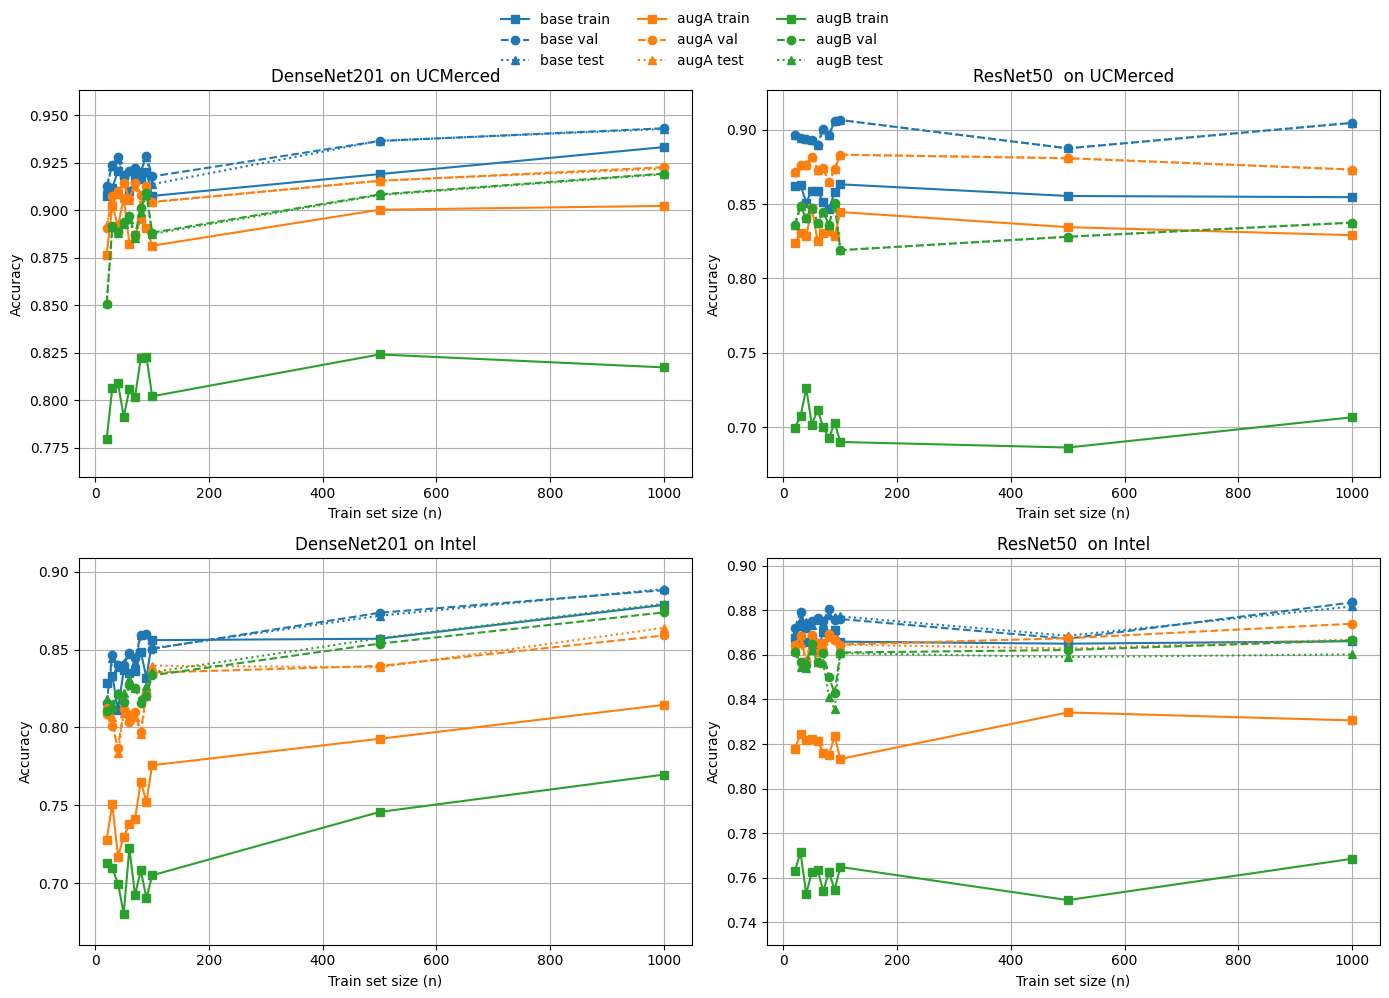

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# 2×2 subplot düzeni
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
combos = [
    (results,         "DenseNet201 on UCMerced"),
    (results_resnet,  "ResNet50  on UCMerced"),
    (results_i_d,     "DenseNet201 on Intel"),
    (results_i_r,     "ResNet50  on Intel")
]

for ax, (data, title) in zip(axes.ravel(), combos):
    # DataFrame’e çevir
    df = pd.DataFrame(data, columns=["n","model","aug","train_acc","val_acc","test_acc"])
    
    # Y eksenini dar bir aralığa kısıtla
    lo = df[["train_acc","val_acc","test_acc"]].min().min() - 0.02
    hi = df[["train_acc","val_acc","test_acc"]].max().max() + 0.02
    ax.set_ylim(lo, hi)
    
    # Her augmentasyon için train/val/test üç çizgi
    colors = {"base":"C0","augA":"C1","augB":"C2"}
    for aug in ["base","augA","augB"]:
        sub = df[df.aug == aug]
        ax.plot(sub.n, sub.train_acc, linestyle='-',  marker='s', label=f"{aug} train", color=colors[aug])
        ax.plot(sub.n, sub.val_acc,   linestyle='--', marker='o', label=f"{aug} val",   color=colors[aug])
        ax.plot(sub.n, sub.test_acc,  linestyle=':',  marker='^', label=f"{aug} test",  color=colors[aug])

    ax.set_title(title)
    ax.set_xlabel("Train set size (n)")
    ax.set_ylabel("Accuracy")
    ax.grid(True)

# Ortak legend’i grafiğin en üstüne al
handles, labels = axes[1,1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
